In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ===== PATH =====
# The main directory containing 'train' and 'valid' folders, which in turn contain 'real' and 'fake'
base_data_path = os.path.join(path, "real_vs_fake", "real-vs-fake") # Corrected path
output_path = "/content/split_data"

split_ratio = (0.7, 0.15, 0.15)  # train, val, test

random.seed(42)

classes = ["real", "fake"]

# Ensure output_path is clean before starting
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# Collect all image paths for each class
all_images_by_class = {cls: [] for cls in classes}

for cls in classes:
    # Iterate through the existing 'train' and 'valid' splits within the original dataset
    for original_split_folder in ["train", "valid"]:
        source_dir = os.path.join(base_data_path, original_split_folder, cls)
        if os.path.exists(source_dir):
            for img_name in os.listdir(source_dir):
                all_images_by_class[cls].append(os.path.join(source_dir, img_name))
        else:
            print(f"Warning: Directory not found: {source_dir}. Skipping.")

# Now, split these collected images into new train, val, and test sets
for cls in classes:
    images = all_images_by_class[cls]
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():
        for img_path in tqdm(split_images, desc=f"Copying {cls} to {split_name}"):
            # Get just the filename from the full path
            img_filename = os.path.basename(img_path)
            dst = os.path.join(output_path, split_name, cls, img_filename)
            shutil.copy(img_path, dst)

print("Dataset Split Completed.")

Copying fake to test: 100%|██████████| 9000/9000 [00:58<00:00, 153.29it/s]

Dataset Split Completed.


In [ ]:
# CLEAN MEMORY

import gc
import tensorflow as tf
gc.collect()
tf.keras.backend.clear_session()


import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix


# STEP 2: PARAMETERS

DATA_PATH = "/content/split_data"   # must contain train/ and test/
IMG_SIZE = 224                     # Xception supports 224+
BATCH_SIZE = 16                    # Safe
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 5


# STEP 3: DATA GENERATORS

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_PATH, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_PATH, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


# STEP 4: BUILD XCEPTION MODEL

base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # Freeze for Phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# PHASE 1 TRAINING

print("\nPHASE 1: Training Top Layers Only\n")

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    verbose=1
)


# PHASE 2: FINE-TUNING

print("\nPHASE 2: Fine-tuning Last 20 Layers\n")

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    verbose=1
)


# FINAL EVALUATION

val_gen.reset()
y_true = val_gen.classes
y_pred = (model.predict(val_gen) > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Found 84000 images belonging to 2 classes.
Found 18000 images belonging to 2 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

PHASE 1: Training Top Layers Only



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1281s 240ms/step - accuracy: 0.6854 - loss: 0.5870 - val_accuracy: 0.7622 - val_loss: 0.5011
Epoch 2/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1200s 229ms/step - accuracy: 0.7361 - loss: 0.5260 - val_accuracy: 0.7766 - val_loss: 0.4814
Epoch 3/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1217s 232ms/step - accuracy: 0.7477 - loss: 0.5134 - val_accuracy: 0.7798 - val_loss: 0.4714
Epoch 4/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1200s 229ms/step - accuracy: 0.7562 - loss: 0.4964 - val_accuracy: 0.7910 - val_loss: 0.4604
Epoch 5/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1191s 227ms/step - accuracy: 0.7642 - loss: 0.4873 - val_accuracy: 0.8003 - val_loss: 0.4463

PHASE 2: Fine-tuning Last 20 Layers

Epoch 1/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1231s 231ms/step - accuracy: 0.7592 - loss: 0.4870 - val_accuracy: 0.9121 - val_loss: 0.2236
Epoch 2/5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 1194s 227ms/step - accuracy: 0.8910 - loss: 0.2624 - val_accuracy: 0.9441 - val_loss: 0.1548
Epoch 3/5
5250/5250 ━━━━

1125/1125 ━━━━━━━━━━━━━━━━━━━━ 77s 69ms/step


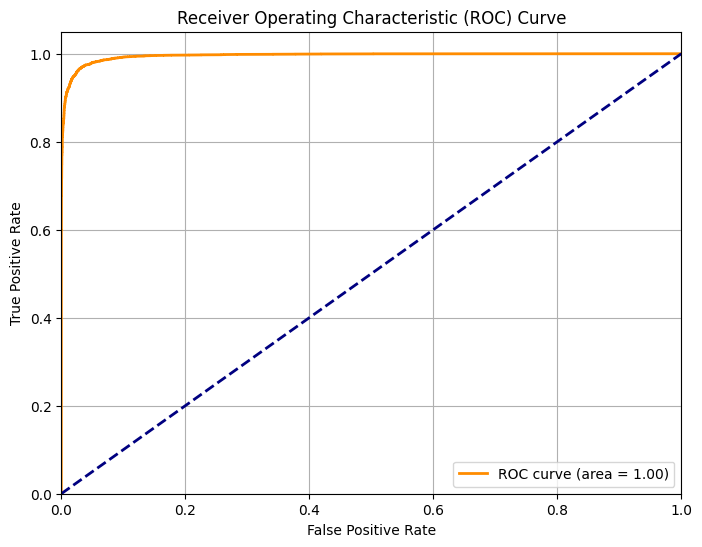

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
val_gen.reset()
y_pred_proba = model.predict(val_gen)

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_true, y_pred)
print(f"Final Model Accuracy: {final_accuracy:.4f}")

Final Model Accuracy: 0.9659
